In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Helper Function for Text Cleaning:

Implement a Helper Function as per Text Preprocessing Notebook and Complete the following pipeline.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# Build a Text Cleaning Pipeline

In [11]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, SnowballStemmer

# Setup resources
nltk.download(['stopwords', 'wordnet', 'punkt'], quiet=True)

def text_cleaning_pipeline(text, method="lemmatize"):
    """
    Advanced cleaning: removes URLs, mentions, special chars, and normalizes.
    """
    # 1. Lowercase and basic cleanup
    text = str(text).lower()

    # 2. Remove URLs, Mentions (@), and Hashtag symbols (keeping the word)
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # URLs
    text = re.sub(r'@\w+', '', text)                 # Mentions
    text = re.sub(r'#', '', text)                    # Hashtag symbol only

    # 3. Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenization & Stopword removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in text.split() if word not in stop_words]

    # 5. Normalization (Using SnowballStemmer as a variation from your friend)
    if method == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
    elif method == "stem":
        stemmer = SnowballStemmer("english")
        tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

tweet = "Trump protests: LGBTQ rally in New York https://t.co/LfHRD9Ft5I by #BBCWorld via @c0nvey"
print(f"Before: {tweet}")
print(f"After cleaning : {text_cleaning_pipeline(tweet, method="lemmatize")}")

Before: Trump protests: LGBTQ rally in New York https://t.co/LfHRD9Ft5I by #BBCWorld via @c0nvey
After cleaning : trump protest lgbtq rally new york bbcworld via


In [12]:
ds_path = "/content/trum_tweet_sentiment_analysis.csv"
df = pd.read_csv(ds_path)

# Ensure columns match instructions
if 'Sentiment' in df.columns:
    df.rename(columns={"Sentiment": "label"}, inplace=True)

df.head()

,text,label
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


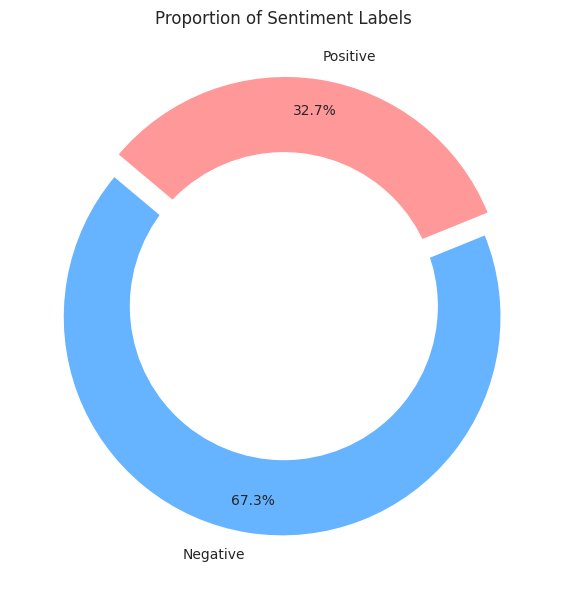

In [19]:
# Create a Donut Chart
plt.figure(figsize=(6, 6))
counts = df['label'].value_counts()
labels = ['Positive' if x == 1 else 'Negative' for x in counts.index]

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=['#66b3ff','#ff9999'], pctdistance=0.85, explode=(0.05, 0.05))

# Draw circle to turn pie into donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Proportion of Sentiment Labels")
plt.tight_layout()
plt.show()

In [15]:
SAMPLE_SIZE = 100_000

if SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_sample = df.copy()

print(f"Working with {len(df_sample):,} rows")

# Drop nulls in text column
df_sample.dropna(subset=["text"], inplace=True)

# Apply cleaning pipeline
print("Cleaning tweets … (this may take ~30–60 s)")
df_sample["clean_text"] = df_sample["text"].apply(
    lambda t: text_cleaning_pipeline(t, method="lemmatize")
)

# Drop rows that became empty after cleaning
df_sample = df_sample[df_sample["clean_text"].str.strip().astype(bool)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_sample):,}")
df_sample[["text", "clean_text", "label"]].head(3)

Working with 100,000 rows
Cleaning tweets … (this may take ~30–60 s)
Rows after cleaning: 99,998


,text,clean_text,label
0,RT @EthandeMarsi: I don't understand why adult...,rt dont understand adult would mean kid age il...,0
1,RT @atrumptastrophe: Suddenly that 3AM call be...,rt suddenly call trump flynn last week value d...,0
2,@RealJeremyNolt~'going after Trump loyalists'f...,going trump loyalistsfor good reasonstrump fam...,1


In [20]:

X = df_sample["clean_text"]
y = df_sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {len(X_train):,}  |  Test size : {len(X_test):,}")
print(f"Train class dist:\n{y_train.value_counts()}")

Train size : 79,998  |  Test size : 20,000
Train class dist:
label
0    53681
1    26317
Name: count, dtype: int64


In [21]:
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")


TF-IDF matrix shape (train): (79998, 50000)
TF-IDF matrix shape (test) : (20000, 50000)


In [22]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train model, print report, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, target_names=["Negative", "Positive"]))


    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)
    auc = roc_auc_score(y_te, y_score)
    print(f"  ROC-AUC: {auc:.4f}")

    return {"model": model_name, "y_pred": y_pred, "auc": auc, "model_obj": model}

In [23]:
# Logistic Regression
lr_results = evaluate_model(
    LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    "Logistic Regression"
)


  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93     13421
    Positive       0.92      0.78      0.84      6579

    accuracy                           0.90     20000
   macro avg       0.91      0.87      0.89     20000
weighted avg       0.90      0.90      0.90     20000

  ROC-AUC: 0.9647


# Text Classification using Machine Learning Models


### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column. This should include:
   - Lowercasing the text  
   - Removing URLs, mentions, punctuation, and special characters  
   - Removing stopwords  
   - Tokenization (optional: stemming or lemmatization)
   - "Complete the above function"

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into **training** and **testing** sets using `train_test_split` from `sklearn.model_selection`.

4. **TF-IDF Vectorization**  
   Import and use the `TfidfVectorizer` from `sklearn.feature_extraction.text` to transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Import **Logistic Regression** (or any machine learning model of your choice) from `sklearn.linear_model`. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.  
   - Print the **classification report** using `classification_report` from `sklearn.metrics`.
